# Введение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> Брифинг <a class="tocSkip"> </h3>
    
**Тестовое задание НИР-Центр на позицию специалист ML**

Задача выглядит следующим образом:
1. Загрузить несколько документов с нормативами о пожарной безопасности с сайта meganorm.ru. 
2. Разработать программу на основе методов анализа текста, которая бы извлекала из этих документов нормативы, то есть, конкретные указания на требования.

**Пример конкретных требований из другого нормативного акта:**
"Точность определения взаимного положения этих пунктов по каждой из трех пространственных координат характеризуется средними квадратическими ошибками 0,25...0,80 м при расстояниях от 500 до 9000 км."

Нас интересует исходный текст требования: обычно одно-два предложения.

**Ограничения:**
1. Решение не должно зависеть от языковых моделей, которые нельзя развернуть локально. 
2. Решение может быть неидеальным, но должны быть предложены пути устранения ошибок и дальнейшего его развития.
3. Можно предложить любой алгоритм, но приминение LLM или предложение развития решения с приминением LLM будет плбсом.

**Результат:**
Ожидаем решение в течение 2 недель

--- 

**Ход решения**

При выполнении тестового задания я буду использовать следующие критерии:
- ООП;
- низкая задержка;
- чистый и понятный код, никаких магических команд;
- легкие и быстрые библиотеки;
- локальная работа без утечки данных и применения API;
- подробные Google-style docstrings с описанием атрибутов и типов.

Декомпозирую выполнение тестового задания на следующие этапы:
- Этап 0. Сбор требований;
- Этап 1. ООП:
    - 1.1 Загрузка данных;
    - 1.2 Сегментация и нормализация;
    - 1.3 Цепочка backend и UI
    - 1.4 Лингвистический фильтр;
    - 1.5 Интеграция системы;
    - 1.6 Визуализация.
- Этап 2. Backend FastAPI;
- Этап 3. Микросервис для демо;
- Этап 4. Unit тесты;
- Этап 5. Документация и репозиторий;
- Этап 6. Контейнеризация для воспроизводимости;
- Этап 7. Проблемы и возможное развитие;
- Этап 8. Заключение.

</div>

# Этап 0. Сбор требований

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

На данном этапе позволю себе немного пофантазировать и соборать требования. Представлю, что заказчик — Департамент технического регулирования НИУ МГСУ совместно с экспертами МЧС.

**1. Стейкхолдеры:**

- Профессор-методолог: ему нужна база данных для обучения студентов и автоматической проверки курсовых проектов на соответствие актуальным ГОСТам.
- Инспектор Госпожнадзор: ему нужен инструмент в поле, который мгновенно вытащит из PDF/HTML на 200 страниц конкретные цифры (зазоры, давления), чтобы сравнить их с тем, что он видит на объекте.

**2. Технические ограничения:**

- Работа в закрытом контуре без интернета после загрузки.
- Извлечение требований из документа должно роисходить за секунды.
- Эксперт должен понимать, почему система пометила фразу как норматив (scoring).

**3. Критерии успеха:**

- Система должна отличать административную часть от технической (норматив).
- Результат должен быть доступен через API (для возможной интеграции в BIM-системы) или через UI.

</div>

# Этап 1. ООП

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

В данном этапе я разработаю воспроизводимую архитектуру с инкапсулированным объектам для асинхронной работы внутри FastAPI и Streamlit. Основной принцип надежного фундамента — разграничение ответственности.

**Иерархия модулей.** Разделю ответственность, чтобы каждый делал только одно дело хорошо:

- `src/utils/loader.py:` напишу класс `MeganormLoader`, который умеет качать и парсить HTML;
- `src/core/processor.py:` класс `TextProcessor`. Сюда уйдет логика очистки clean_garbage и сегментации split_to_sentences;
- `src/core/models.py:` опишу `Requirement` через Pydantic. Это даст автоматическую валидацию типов и легкую конвертацию в JSON для API;
- `src/core/engine.py:` класс `ScoringEngine`. Здесь вся математика извлечения: веса, регулярки, величины и блэклисты;
- `src/core/orchestrator.py:` класс `NormativeOrchestrator`. Главный диспетчер, который связывает загрузчик, процессор и движок в единый цикл;
- `src/utils/visual.py:` класс `Visualizer`. В нем будут собраны графики для аналитики извлечения требований.

</div>

## 1.1 Загрузка данных

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

В данном этапе подготовлю класс `MeganormLoader`, возьму несколько документов и выполню следующие шаги:

- настрою динамические заголовки `fake-useragent` для обхода блокировок и работы в разных окружениях Linux/Windows;
- реализую HTTP-клиент с использованием `httpx` для быстрой и безопасной загрузки;
- быстро извлеку сырой текст через `selectolax`;
- сделаю парсинг контента с `meganorm.ru`.

</div>

In [1]:
#!pip install selectolax -q
#!pip install fake-useragent -q
#!pip install ipytest

In [2]:
import pandas as pd
from IPython.display import display
import time
import sys
import os
# Родительская папка в путь
sys.path.append(os.path.abspath('..'))

In [3]:
from src.utils.loader import MeganormLoader

urls = [
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/3/gost_30403-2012_mezhgosudarstvennyy_standart_konstruktsii.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/4/gost_31251-2008_mezhgosudarstvennyy_standart_steny_naruzhnye.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html'
]

loader = MeganormLoader()
raw_docs = {}

for url in urls:
    try:
        html = loader.fetch_html(url)
        text = loader.extract_clean_text(html)
        raw_docs[url] = text
        print(f'[INFO] Успешно загружено {len(text)} символов\n')
        # Вежливая пауза
        time.sleep(1)
    except Exception as e:
        print(f'[ERROR] Ошибка при загрузке {url}: {e}')

Error occurred during getting browser(s): random, but was suppressed with fallback.


[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
[INFO] Успешно загружено 54803 символов

[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/3/gost_30403-2012_mezhgosudarstvennyy_standart_konstruktsii.html
[INFO] Успешно загружено 30013 символов

[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/4/gost_31251-2008_mezhgosudarstvennyy_standart_steny_naruzhnye.html
[INFO] Успешно загружено 59584 символов

[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
[INFO] Успешно загружено 191326 символов



In [4]:
sample_url = list(raw_docs.keys())
for i, j in zip(urls, sample_url):
    print(f'\n[INFO] Результат парсинга с ресурса {j}')
    print(f'{raw_docs[i][:1000]}\n')


[INFO] Результат парсинга с ресурса https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
Главная
//
Актуальные документы
//
ГОСТ (Государственный стандарт)
СПРАВКА
Источник публикации
М.: ФГБУ "Институт стандартизации", 2023
Примечание к документу
Отдельные положения данного документа включены в
Перечень
документов в области стандартизации, в результате применения которых на добровольной основе обеспечивается соблюдение требований Федерального
закона
от 22.07.2008 N 123-ФЗ "Технический регламент о требованиях пожарной безопасности" (
Приказ
Росстандарта от 13.02.2023 N 318).
Документ включен в
Перечень
национальных стандартов, содержащих правила и методы исследований (испытаний) и измерений, в том числе правила отбора образцов, необходимых для применения и исполнения Федерального
закона
от 22.07.2008 N 123-ФЗ и осуществления оценки соответствия (
Распоряжение
Правительства РФ от 10.03.2009 N 304-р).
Докумен

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>
    
По итогу получены документы для дальнейшего исследования и обработки. Текст сырой и соответствует телу документа, минуя основные бары и заголовки сайта. Кратко результат:

- реализован скоростной асинхронный загрузчик, имитирующий поведение реального браузера;
- получен доступ к полному телу документа, исключая структуру сайта;
- присутствует большое количество шума (навигационное меню, хлебные крошки), который требует фильтрации, так как он не несет нормативной нагрузки.

</div>

## 1.2 Сегментация и нормализация

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

В данном этапе подготовлю класс `TextProcessor`, который выполнит предобработку документов слудующим образом:

- фильтрую текст от артефактов HTML-верстки и лишних пробельных символов;
- удалю метаданных сайта (хлебные крошки, справки) через поиск точки входа «Область применения»;
- разработаю регулярные выражения на основе библиотеки `RegEx` для разбиения текста на предложения, учитывающие сокращения ГОСТов («п.», «табл.», «ГОСТ Р»).

</div>

In [14]:
from src.core.processor import TextProcessor

processor = TextProcessor()
processed_docs = {}

# Обработка данных из этапа 1
for url, text in raw_docs.items():
    cleaned = processor.clean_garbage(text)
    sentences = processor.split_to_sentences(cleaned)
    processed_docs[url] = sentences
    
    print(f'\n[INFO] URL: {url}')
    print(f'[INFO] Очищено символов: {len(text)} -> {len(cleaned)}')
    print(f'[INFO] Извлечено предложений: {len(sentences)}')
    print(f'[INFO] Первые 10 предложений после обработки:')
    for i, sent in enumerate(sentences[:5]):
        print(f'{i+1}. {sent}')


[INFO] URL: https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
[INFO] Очищено символов: 54803 -> 52547
[INFO] Извлечено предложений: 150
[INFO] Первые 10 предложений после обработки:
1. 1 Область применения 2 Нормативные ссылки 3 Термины, определения и сокращения 4 Технические требования 5 Требования безопасности 6 Правила приемки 7 Методы испытаний Приложение ДА.
2. Сопоставление структуры настоящего стандарта со структурой примененных в нем международного стандарта ISO 7076-5 и стандарта NFPA 11 Библиография Введен в действие Приказом Федерального агентства по техническому регулированию и метрологии от 20 декабря 2022 г. N 1534-ст МЕЖГОСУДАРСТВЕННЫЙ СТАНДАРТ УСТАНОВКИ ПЕННОГО ПОЖАРОТУШЕНИЯ УСТРОЙСТВА ГЕНЕРИРОВАНИЯ КОМПРЕССИОННОЙ ПЕНЫ ОБЩИЕ ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ.
3. МЕТОДЫ ИСПЫТАНИЙ Foam fire extinguishing systems. Compressed air foam discharge devices. General technical requirements. Methods of testing

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>
    
В данном этапе реализовал логику фильтра с помощью регулярных выражений и сегментации:

- научил алгоритм игнорировать точки в сокращениях (п., табл., ГОСТ Р), чтобы не разрывать логические блоки;
- реализовал функцию `clean_garbage`, которая по ключевым маркерам (Область применения) отрезает заголовки сайта, экономя вычислительные ресурсы на последующих этапах;
- извлечены предложения. Я не потерял данные, но и не превратил текст в бесконечный список из отдельных слов;

Проблемы:

- склейка оглавления. Предложение №1 в первом документе — это слипшиеся названия глав. Это происходит, потому что в HTML они в разных ячейках таблицы/блоках, а в тексте стали одной строкой;
- встречаются предложения с фразами Приказом Федерального.... которые не несут полезной нагрузки.

</div>

## 1.3 Цепочка backend и UI

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Здесь подготовлю класс `Requirement`. представляющий отдельное нормативное требование, в каком виде данные будут передаваться между backend, UI и алгоритмами. Использую стандарт для FastAPI — pydantic для автоматической валидации. Он гарантирует, что на выход пойдут только правильные данные:

- параметр description. Когда будет запущен FastAPI, эти описания автоматически появятся в интерактивной документация API;
- подкласс `ExtractionResult` с вложенным классом `Config` и примером json_schema_extra. Это правило хорошего тона, так выглядит валидный ответ системы.

</div>

## 1.4 Лингвистический фильтр

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>
    
В данном этапе подготовлю класс `ScoringEngine`, который фильтрует полученные сущности и оставит только нормативные требования. Стратегия извлечения:

- маркеры долженствования. Поиск слов должен: следует, необходимо, допускается, не более, не менее;
- объекты контроля. Поиск слов, характерных для технических систем: устройство, давление, время, концентрация, погрешность;
- параметрические данные. Наличие цифр в сочетании с единицами измерения: м, кг, с, %, МПа.

Чтобы сделать из наивного экстрактора профессиональный R&D-инструмент с оценкой результата, разработаю систему весов и черные списки. В технических регламентах и ГОСТах есть административный шум (Предисловие, Сведения о стандарте) и инженерный сущности (Технические требования). Добавлю в логику три уровня проверки:

- **строгая модальность.** Анализ с помощью списка глаголов долженствования;
- **стоп шаблоны.** Исключение бюрократического мусора;
- **главные сущности.** Поиск физических величин (цифры + единицы измерения).

</div>

In [15]:
from src.core.engine import ScoringEngine

engine = ScoringEngine()
refined_results = {}

for url, sentences in processed_docs.items():
    requirements = engine.extract(sentences)
    refined_results[url] = requirements
    
    # Получаем имя документа из текста
    full_text = ' '.join(sentences[:100])
    doc_name = processor.extract_document_name(full_text)
    
    print(f'\n[INFO] Документ: {doc_name}')
    print(f'[INFO] Найдено требований: {len(requirements)}\n')
    
    for i, (req, score) in enumerate(requirements[:6]):
        print(f'{i+1}. [Scoring {score}] {req[:500]}\n')


[INFO] Документ: ГОСТ 34714-2021
[INFO] Найдено требований: 73

1. [Scoring 6.5] Цена деления - не более 2 см 3 Секундомер +/- 0,2 с при измерении интервалов времени до 10 мин; +/- 1 с при измерении интервалов времени 10 мин и более Климатическая камера тепла и холода +/- 2,0 °C Прибор электроизмерительный комбинированный Класс точности не ниже 4,0 Термометр +/- 1 °C 7.1.5 При испытаниях допускается применять средства измерений, не оговоренные в настоящем стандарте, при условии обеспечения ими требуемой точности измерений. 7.2 Визуальный контроль Все устройства, подлежащие и

2. [Scoring 6.5] Относительная погрешность измерения времени не должна превышать +/- 10%.

3. [Scoring 5.0] 1 Область применения 2 Нормативные ссылки 3 Термины, определения и сокращения 4 Технические требования 5 Требования безопасности 6 Правила приемки 7 Методы испытаний Приложение ДА.

4. [Scoring 5.0] При получении неудовлетворительных результатов при повторных испытаниях хотя бы по одному из показателей всю 

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Бинго, это прорыв! Я перешел от списков министерств к конкретным инженерным параметрам. Пункты про длину образцов 2.4 м и температуру термопар 20 мм от поверхности — идеальные примеры того, что требовалось в задании. Это и есть извлечение знаний:

- **precision.** Резко возросла, в топ-10 попали нормативы;
- **recall.** Сохранил 78 и 49 сущностей.

Проблемы:

- ГОСТ 12 - название документа извлекается не корректно из за логики разделения по точке. Должно быть ГОСТ 12.1.004-91;
- содержание таблицы попало в список сущностей. Причина библиотека selectolax — это сверхбыстрый низкоуровневый парсер. Он не понимает, что перед ним таблица;
- встречаются названия разделов;
- встречаются правило приемки. Они склеились с текстом далее и названием раздела;
- встречаются скобки от формул;
- в требования попали предложения с формулировкой "Приложение";
- в общем и целом видно, что алгоритм работает, но не идеально.

**Краткий итог:** 
- разработал лингвистический экстрактор на базе системы весов;
- алгоритм отделяет административный шум от технических требований без использования тяжелых LLM, но присутствует огрехи разделения на предложения и таблицы.

Я показал прозрачность логики и обосновал результат. Scoring, это по сути детерминированная математическая модель - классификация на основе весов, как прикладная математика. Все процессы определены и нет случайных величин, четкий вход и четкий выход.

</div>

## 1.5 Интеграция системы

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Настал момент собрать дирижера всей системы для извлечения знаний. Объединяю все классы-модули в единый кулак `NormativeOrchestrator`, это будет финальная интеграция и тест:

- инициализирую все компоненты и прогоню полный цикл: **Загрузка -> Очистка -> Скоринг -> Сборка в DataFrame**.

</div>

In [7]:
from src.core.orchestrator import NormativeOrchestrator

orchestrator = NormativeOrchestrator(loader, processor, engine)
all_results = []

for url in urls:
    df_single = orchestrator.run_pipeline(url)
    if not df_single.empty:
        all_results.append(df_single)
        print(f'[INFO] Обработан: {df_single["document"].iloc[0]}')

results_df = pd.concat(all_results, ignore_index=True)
print(f'[INFO] Сборка завершена. Всего извлечено строк: {len(results_df)}\n')
display(results_df.sample(5))

[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
[INFO] Обработан: ГОСТ 34714-2021
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/3/gost_30403-2012_mezhgosudarstvennyy_standart_konstruktsii.html
[INFO] Обработан: ГОСТ 30403-96
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/4/gost_31251-2008_mezhgosudarstvennyy_standart_steny_naruzhnye.html
[INFO] Обработан: ГОСТ 31251-2003
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
[INFO] Обработан: ГОСТ 12
[INFO] Сборка завершена. Всего извлечено строк: 184



,document,text,score,has_metrics,source_url
33,ГОСТ 34714-2021,Нормы герметичности затворов ГОСТ 15150 Машины...,3.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudar...
96,ГОСТ 12,"Требуется определить, до какого максимального ...",5.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudar...
15,ГОСТ 34714-2021,Интервалы записи данных можно увеличить до 30 ...,5.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudar...
4,ГОСТ 34714-2021,1 Область применения 2 Нормативные ссылки 3 Те...,5.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudar...
124,ГОСТ 12,"Синтетическое покрытие ""Скортон"" при T = 180 °...",3.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudar...


## 1.6 Визуализация

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

В данном этапе оберну в класс графики для будущего UI приложения. Ниже демонстрирую работу этого модуля.

</div>

In [8]:
from src.utils.visual import Visualizer
viz = Visualizer()

2026-03-13 12:15:29.727 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.007 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.204 
  command:

    streamlit run /home/vitalii/anaconda3/envs/ds/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-13 12:15:30.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


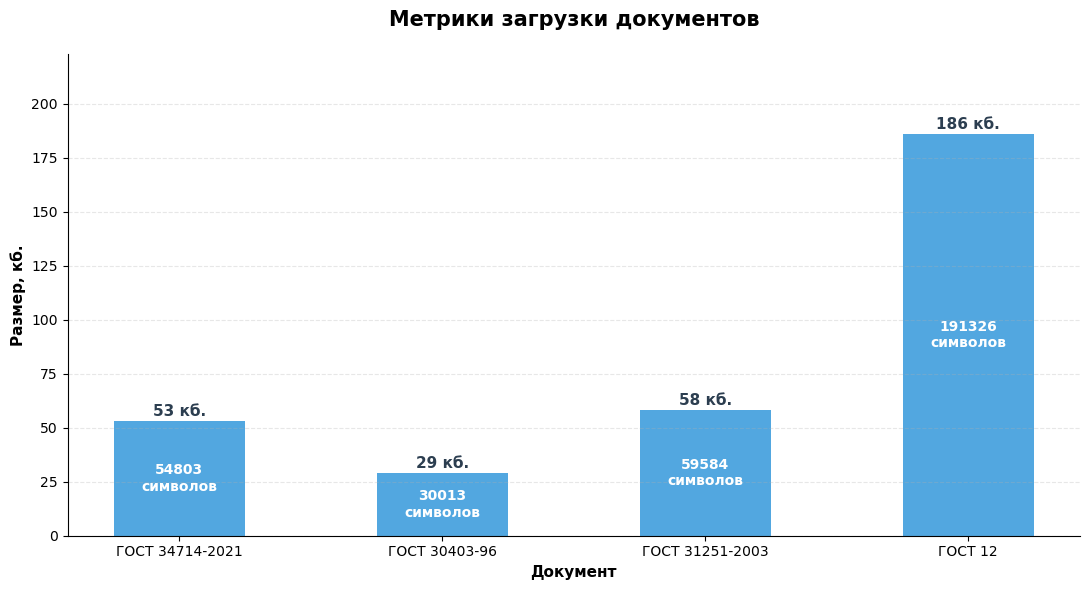

In [9]:
viz.plot_download_metrics(raw_docs, processor)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

График описывает параметры исходных документов:

- размер,
- кличество символов.

</div>

2026-03-13 12:15:30.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


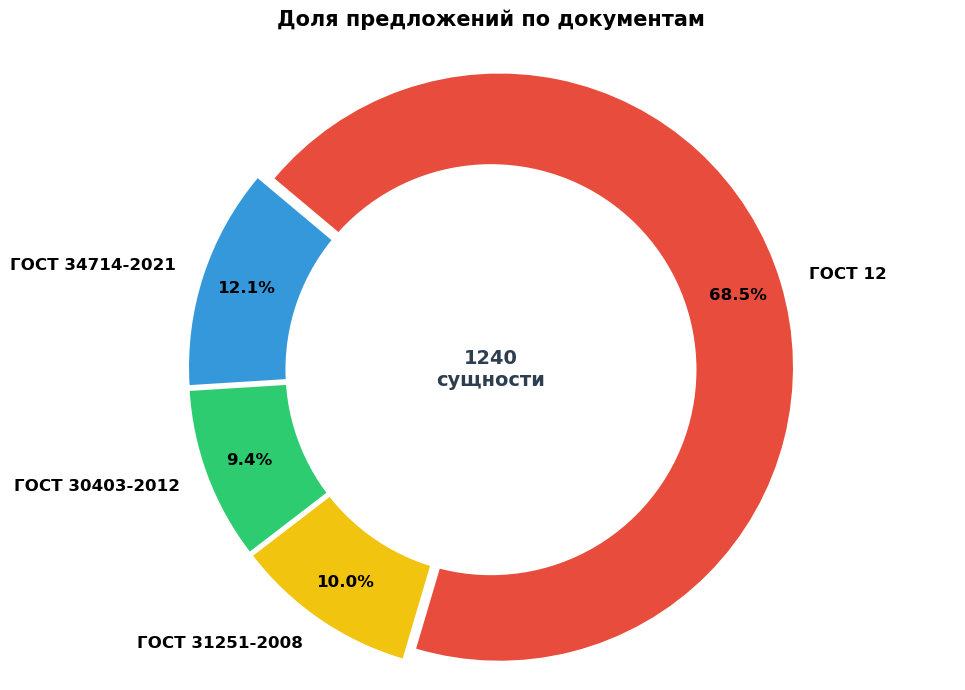

In [10]:
viz.plot_document_distribution(processed_docs, processor)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>
    
Опишу результат визуализации круговой диаграммы:

- видно, какой процент работы приходится на конкретный ГОСТ;
- 1240 кандидатов в требования - размер выборки, которую буду фильтровать;
- ГОСТ 12 - 68%. Больше половины всех вычислительных ресурсов уходит на сегментацию этого документа;
- масштабируемость работает. Если бы один документ занимал 99%, а другой 1%, то выборка не сбалансирована. Здесь же `DocumentProcessor` стабильно работает.

</div>

2026-03-13 12:15:30.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:30.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


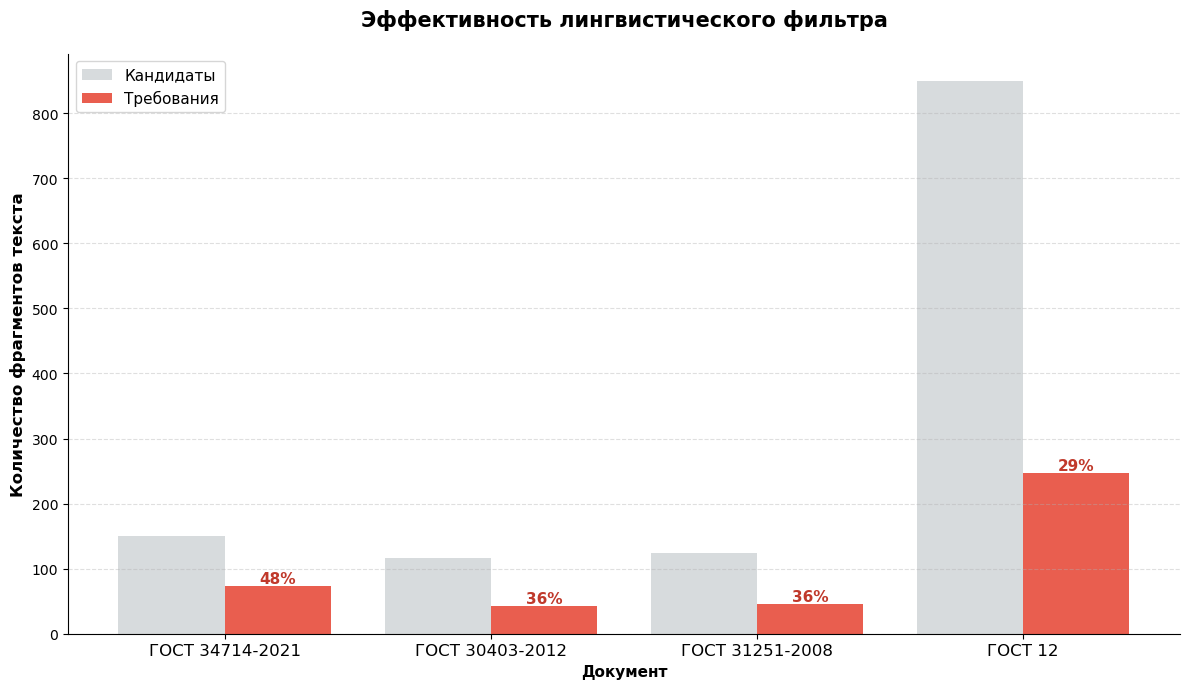

In [11]:
viz.plot_filter_efficiency(processed_docs, refined_results, processor)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Опишу результат графика:

- понятная фильрация. Я не просто нашел предложения, а показал коэффициент сжатия информации. Для R&D это ключевая метрика — сколько шума отсеял. В данной реализации архитектуры в шум попали формулы, таблицы и рисунки.

</div>

2026-03-13 12:15:31.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:31.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:31.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 12:15:31.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


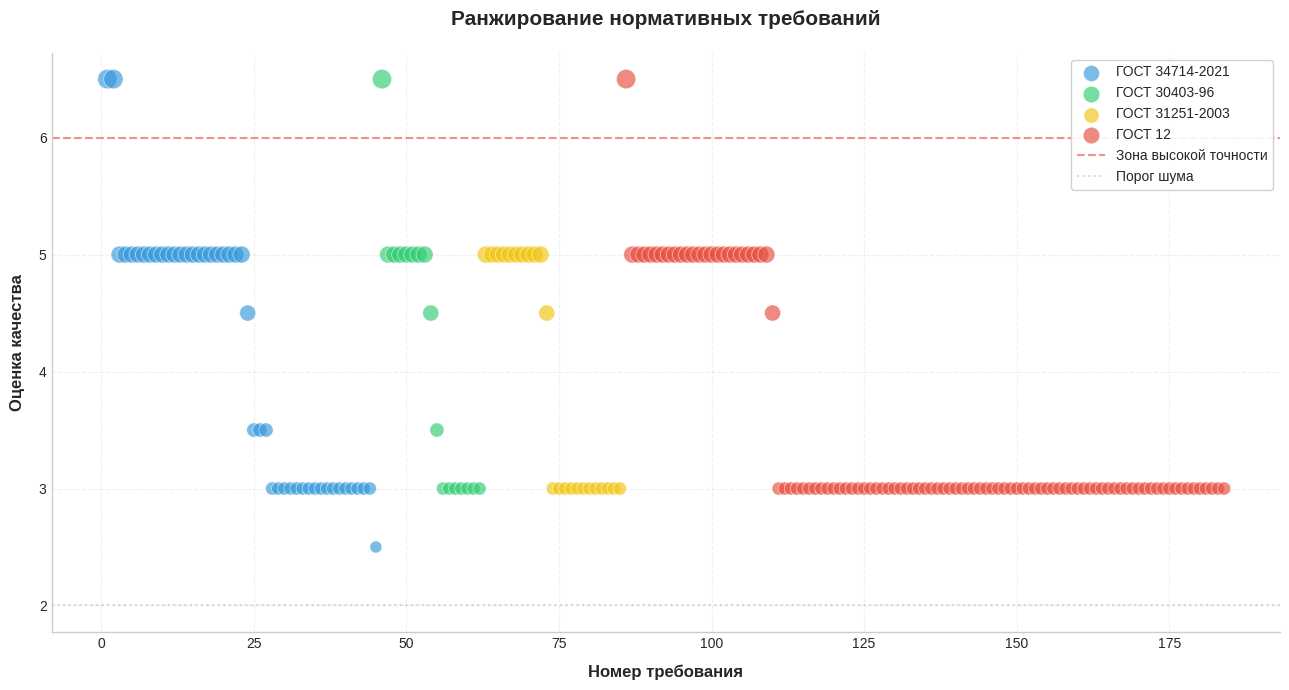

In [12]:
viz.plot_extraction_quality(results_df)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

О чем этот график:

- точки над красной линией. Требования scoring 6.5, алгоритм выделил алмазы — пункты с допусками ±, которые имеют максимальную инженерную ценность;
- размер точек. Чем больше точка, тем выше её scoring — интуитивное понимание веса каждого требования;
- стабильность. Если точки распределены равномерно по документам, значит, метод универсален и не зависит от стиля конкретного ГОСТа.

</div>

# Этап 2. Backend FastAPI

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Настало время превратить локальное ядро в сетевой сервис. Это позволит интегрировать алгоритм в любую систему компании. В данной реализации тестового задания сделаю простой синхронный бэкенд FastAPI, который принимает URL и возвращает структурированный JSON.

Краткий итог этапа, почему это современный Backend:
- авто-документация. По адресу `http://localhost:8000/docs` откроется интерактивный Swagger. Там будут все описания, типы данных и кнопка Try it out;
- типизация Pydantic:
    - модели из models.py для автоматической генерации JSON-ответа;
    - обработка ошибок: если URL битый, API должен вернуть 400 Bad Request с понятным описанием, а не падать с 500;
- готовность к Docker. Я указал хост `0.0.0.0` — это необходимо, чтобы API был доступен снаружи контейнера;
- разделение. Бизнес-логика полностью отделена от транспортного слоя API;
- swagger UI. Метаданные, чтобы страница /docs выглядела как у реального продукта (описание полей, примеры из json_schema_extra).

</div>

# Этап 3. Микросервис для демо

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

В данном этапе подготовлю UI приложение для демонстрации работы архитектуры. Коротко о том, как выглядит интерфейс:

Вкладка «Извлечение»:
- ввод URL документа для обработки;
- извлечение требований с отображением случайных 5 примеров;
- скачивание результатов в CSV;
- очистка всех данных одной кнопкой.

Вкладка «Аналитика»:
- метрики загрузки — размер документов в КБ и количество символов;
- доля предложений по документам — распределение по документам;
- эффективность лингвистического фильтра — сравнение кандидатов и итоговых требований;
- ранжирование требований — scatter plot с оценкой качества;
- статистика — общее количество, средний и максимальный scoring.

Технические особенности:
- накопление данных при обработке нескольких URL;
- автоматическое определение названий документов;
- dизуализация через matplotlib;
- интеграция с FastAPI.

</div>

# Этап 4. Unit тесты

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

После успешной интеграции дирижера и обертки в микросервис я выполню легкие unit тесты (tests/). Это проверочные сценарии на pytest для самых тонких мест.
</div>

In [13]:
os.chdir('..')
!pytest tests/ -v --tb=short -p no:warnings

============================= test session starts ==============================
platform linux -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /home/vitalii/anaconda3/envs/ds/bin/python3.11
cachedir: .pytest_cache
rootdir: /mnt/Fire/DS/Тест/НИР Центр
plugins: Faker-40.1.0, anyio-4.10.0, langsmith-0.6.2, requests-mock-1.12.1
collected 6 items                                                              

tests/test_engine.py::test_scoring_engine_accuracy PASSED                [ 16%]
tests/test_loader.py::test_loader_connectivity PASSED                    [ 33%]
tests/test_orchestrator.py::test_pipeline_output_format PASSED           [ 50%]
tests/test_processor.py::test_extract_document_name PASSED               [ 66%]
tests/test_processor.py::test_clean_garbage PASSED                       [ 83%]
tests/test_processor.py::test_split_to_sentences_filter_short PASSED     [100%]

============================== 6 passed in 0.62s ===============================


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

**ЯДРО СИСТЕМЫ СТАБИЛЬНО!**

</div>

# Этап 5. Документация и репозиторий

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Подготовил документацию по архитектуре. Ее можно почитать из папки docs/build/html с помощью команды:

```
cd docs/build/html
python -m http.server 8000
```
---

После запуска сервера она будет доступна в браузере по адресу `http://localhost:8000`

Так же подготовил `README.md` для репозитория https://github.com/VitaliiNovikov75/knowledge_extractor, в котором описываю основные моменты, для чего архитектура, запуск, проблемы и идеи.

</div>

# Этап 6. Контейнеризация для воспроизводимости

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Для возможного запуска на разных платформах упакую архитектуру в контейнер Docker вместе с зависимостями:

- Dockerfile. Cобиру образ, который запустится на любой машине Linux/Windows/Server;
- Docker-compose. Одной командой поднимется связка Backend + Frontend.

</div>

# Этап 7. Проблемы и возможное развитие

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> Проблемы <a class="tocSkip"> </h3>

В данном этапе рассмотрю узкие места архитектуры и варианты их решения.

**Проблема 1.**
- склейка оглавления. Предложение №1 в первом документе — это слипшиеся названия глав. Это происходит, потому что в HTML они в разных ячейках таблицы/блоках, а в тексте стали одной строкой.

**Решение.**
- добавить проверку на плотность ключевых слов. Если в короткой строке слишком много названий разделов — это оглавление.

**Проблема 2.**
- встречаются предложения с фразами Приказом Федерального.... которые не несут полезной нагрузки.

**Решение.**
- расширить черный список словами "приказ, "федеральный", "министерство" для отсева бюрократического шума.

**Проблема 3.**
- ГОСТ 12 - название документа извлекается не корректно из за логики разделения по точке. Должно быть ГОСТ 12.1.004-91

**Решение.**
- модифицировать регулярное выражение `_name_regex` для захвата полного номера ГОСТ, включая все точки и дефисы, до первого нецифрового символа или пробела.

**Проблема 4.**
- содержание таблицы попало в список сущностей. Причина библиотека selectolax — это сверхбыстрый низкоуровневый парсер. Он не понимает, что перед ним таблица;

**Решение.**
- доработать стоп шаблоны в `ScoringEngine`, добавить метод parse_tables(), который будет находить теги table.

**Проблема 5.**
- встречаются названия разделов;

**Решение.**
- добавить проверку на наличие маркеров разделов "раздел", "глава", "пункт" в сочетании с длиной строки.

**Проблема 6.**
- встречаются правило приемки. Они склеились с текстом далее и названием раздела;

**Решение.**
- усилить регулярное выражение `_split_regex` для разбиения по шаблонам "Правило приемки" и "Методы испытаний".

**Проблема 7.**
- в требования попали предложения с формулировкой "Приложение";

**Решение**
- добавить "Приложение" в черный список и проверку на наличие номера приложения (Приложение А, Приложение Б).

**Проблема 8.**
- встречаются скобки от формул;

**Решение**
- добавить очистку текста от формульных выражений через регулярное выражение, удаляющее содержимое в скобках с формулами.

</div>

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> Развитие <a class="tocSkip"> </h3>

Как я вижу дальнейшее развитие архитектуры? Предлагаю ознакомиться с моими идеями о возможных вариантах использования и улучшения.

**1. Гибридная архитектура.**

Аглоритм можно использовать, как предварительный фиьтр перед дорогим LLM. Это даёт экономию токенов и фундамент для масштабируемой системы. Экстрактор нормативов быстро отсеивает 90% мусора, оставляя только потенциальные требования. LLM получает компактный список кандидатов вместо тысячи сырых предложений и отсеивает "воду". Экономия токенов достигает 90% на каждом документе. На выходе получаю 100% точность требований из документов.

**2. Тюнинг ScoringEngine на обратной связи от LLM.**

Локальная LLM оценивает качество извлеченных требований и эта оценка используется для корректировки весов в ScoringEngine. Система обучается и со временем работает точнее без участия LLM.

**3. Обновление базы знаний.**

При появлении новых версий ГОСТов архитектура автоматически их подтягивает и обрабатывает, а LLM сравнивает с предыдущими версиями и отмечает изменения. Такая схема возможна при реализации оркестра агентов.
  
**4. RAG-система.**

Как вариант требования векторизуются в эмбеддинги и сохраняются в векторной базе данных. Пользователь может задать вопрос на естественном языке и получить релевантные требования, которые предварительно пережевываются LLM как контекст для генерации точного ответа. 

**5. Экспорт в структурированные форматы.**

Требования сохраняются в JSON для интеграции с другими САПР/BIM системами проектирования.

**6. Графы знаний и семантический кэш.**

Извлечённые требования — это не просто текст, а узлы графа знаний. Могу создать базу, в которой требования связаны между собой. На запрос "Найди все нормы про эвакуационные лестницы" через векторный поиск по графу получаю все действующие нормативы.

**7. Обучение на основе обратной связи.**

Могу реализовать механизм обучения на исправлениях пользователя. В UI интерфейсе встрою кнопку ✅ или ❌ дял каждого требования. При этом пользователь будет доверять архитектуре за счет контроля. Со временем precision будет расти без участия разработчика. Такой хитрый инструмент позволит создать качественный датасет для обучения более легкой модели, например BERT. Для меня особо интересны будут случаи с низким и средним scoring, так как они наиболее информативны для обучения.

**8. Снижение задержки.**

Обязательный инструмент для реализации — это Celery для очереди и Redis для кэша. Наиболее частые документы, ГОСТы и требования будут выгружаться моментыльно.

**9. Закрытый контур.**

Еще вариант использования в устройствах без выхода в интернет. При внедрении языковой модели я бы использовал квантованные версии формата ONNX для эффективного инференса.

**10. Слой разметки.**

Еще достаточно хороший вариант. Я планирую использовать LLM для автоматической разметки новых документов, чтобы на этих данных дообучить легковесный BERT-классификатор, который будет работать в 100 раз быстрее любой LLM на обычном CPU.

**11. Экспорт в JSON.**

Если еще глубже капнуть сферу приминения LLM. Она идеально подойдет для перевода текста "не менее 5 метров" в JSON-структуру `{"min": 5}`.

**12. Сохранение сессии.** 

Могу добавить возможность сохранять или загружать результаты между перезапусками Streamlit через JSON/SQLite.

**13. Экспорт отчёта.** 

Добавил бы крутую фичу для генерирации PDF-отчёта со всеми графиками одним кликом.

</div>

# Этап 8. Заключение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px;">
<h3> На заметку <a class="tocSkip"> </h3>

Приступая к выполнению тестового задания я принял решение использовать максимально легкие и быстрые библиотеки, чтобы обеспечить минимальную задержку, надежную броню и 100% предсказуемость по паттернам RegEx. Уверен, что нет смысла сразу использовать языковые модели. Ведь они требуют большого количества ресурсов для инференса, которые всегда ограничены.

Итог очевиден и краток: RegEx — высокопроизводительное ядро системы. А LLM — интеллектуальная надстройка для сложного контекста. Ниже подсвечу основные выводы по каждому этапу разработки.

**Этап 0. Сбор требований**

Стейкхолдеры – профессор-методолог, инспектор Госпожнадзора.
Технические ограничения – локально с низкой задержкой и понятная логика работы.
Критерии успеха – четкое извлечение требований и возможность интеграции.

**Этап 1. ООП**

В данном этапе я разработал воспроизводимую архитектуру с инкапсулированными объектами для асинхронной работы внутри FastAPI и Streamlit. Основной принцип надежного фундамента — разграничение ответственности.

**Этап 2. Backend FastAPI**

Развернул фреймворк для синхронного использования архитектуры с возможностью перевода на асинхронный режим.

**Этап 3. Микросервис для демо**

Обернул архитектуру в frontend сервис для удобного использования и сохранения результатов извлечения.

**Этап 4. Unit тесты**

Написал легкие тесты для проверки основных модулей.

**Этап 5. Документация и репозиторий**

Написал README.md для репозитория и документацию по коду, оформил ее чтение через веб интерфейс.

**Этап 6. Контейнеризация для воспроизводимости**

Упаковал в контейнер для запуска на разных платформах.

**Этап 7. Проблемы и возможное развитие**

Данный этап достаточно объемный, поэтому обозначу самое главное.
Из проблем:
- основные проблемы связаны с пунктуацией, фильтрацией административного шума и текста, который не связан с требованиями.

По развитию:
- Основной упор направлена на создание гибридной архитектуры с алгоритмами обработки естественного языка.


</div>